<a href="https://colab.research.google.com/github/Samuromarin/Retail-Sales-Forecasting/blob/main/retail_sales_forecasting.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Retail Sales Forecasting** 📈

Proyecto de series temporales sobre ventas de **TodoVentas S.A.** con el objetivo de predecir las ventas de diciembre 2023 por país, en el contexto de una decisión de ampliación de capital.

## **Contexto de Negocio**

**TodoVentas S.A.** es una empresa de retail online con presencia en 10 países europeos. La dirección financiera necesita una **previsión de ventas para el mes de diciembre de 2023** para justificar ante los accionistas una ampliación de capital.

El objetivo de este análisis es:
1. Explorar y entender la serie histórica de ventas (dic 2022 - dic 2023).
2. Modelar las ventas usando tres modelos distintos: **Prophet**, **SARIMAX** y **XGBoost**.
3. Seleccionar el modelo más adecuado y generar la predicción final por país.

**Decisiones de modelado adoptadas:**
- Trabajaremos con **frecuencia semanal**: con solo ~13 meses de histórico, la frecuencia diaria introduce demasiado ruido y la mensual nos dejaría con muy pocas observaciones para modelar.
- **United Kingdom** se analiza de forma independiente por representar el **93% de las ventas totales**.
- Las semanas de **cierre navideño** se rellenan con 1 para no distorsionar los modelos.

## **Tabla de Contenidos**

1. [Introducción y Preprocesamiento](#introducción-y-preprocesamiento)
   - Análisis exploratorio
   - Productos más vendidos
   - Agregación semanal por país
2. [Serie Temporal: UK](#serie-temporal-uk)
   - Análisis (ventas diarias, evolución, descomposición, ADF, ACF/PACF)
   - Modelos: Prophet, SARIMAX, XGBoost
   - Comparativa
   - Variables Exógenas
   - Predicción Diciembre 2023
3. [Serie Temporal: Otros países](#serie-temporal-otros-países)
4. [Predicción Final TodoVentas S.A](#predicción-final-todoventas-sa)
5. [Conclusiones](#conclusiones)

# **1. Introducción y Preprocesamiento**

Nombre de Variable      |   Descripción
------------------------| ----------------------------------------------------------
Número de Factura       |  Un número integral de 6 dígitos asignado de forma única a cada transacción. Si comienza con la letra 'c', indica una cancelación.
Código de Stock         |  Un número integral de 5 dígitos asignado de forma única a cada producto distinto.
Descripción             |  Nombre del producto.
Cantidad                |  Las cantidades de cada producto (ítem) por transacción.
Fecha de Factura        |  El día y la hora en que se generó cada transacción.
Precio Unitario         |  Precio del producto por unidad en libras esterlinas.
ID de Cliente           |  Un número integral de 5 dígitos asignado de forma única a cada cliente.
País                    |  El nombre del país donde reside cada cliente.

In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import plotly.express as px
import seaborn as sns

import time
from datetime import datetime, timedelta
from math import sqrt
import warnings
warnings.filterwarnings("ignore")


from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller
from scipy import stats
from statsmodels.graphics.tsaplots import plot_acf

from prophet import Prophet
from prophet.plot import plot, plot_components
from prophet.diagnostics import cross_validation, performance_metrics
from prophet.plot import plot_cross_validation_metric

from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
from pmdarima import auto_arima
from sktime.forecasting.naive import NaiveForecaster
from sktime.forecasting.compose import make_reduction
from sktime.forecasting.base import ForecastingHorizon
from sktime.utils.plotting import plot_series

from xgboost import XGBRegressor
from sktime.performance_metrics.forecasting import mean_absolute_percentage_error as mape_sktime
from sktime.transformations.series.detrend import Deseasonalizer, Detrender
from sktime.transformations.series.boxcox import BoxCoxTransformer
from sktime.forecasting.trend import PolynomialTrendForecaster
from sktime.forecasting.compose import TransformedTargetForecaster


from sklearn.metrics import mean_squared_error, mean_absolute_error, mean_absolute_percentage_error

pd.set_option('display.float_format', lambda x: '%.2f' % x)

### **Análisis exploratorio**

#### **df_productos**

In [ ]:
try:
    from google.colab import drive
    drive.mount('/content/drive')
    DATA_PATH = '/content/drive/MyDrive/data_TodoVentas/'
except ImportError:
    DATA_PATH = 'data_TodoVentas/'


df_productos = pd.read_csv(DATA_PATH + "prod_dict.csv")
df_productos.head()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


,StockCode,Description
0,10002,INFLATABLE POLITICAL GLOBE
1,10080,GROOVY CACTUS INFLATABLE
2,10120,DOGGY RUBBER
3,10125,MINI FUNKY DESIGN TAPES
4,10133,COLOURING PENCILS BROWN TUBE


In [ ]:
df_productos.shape

(3922, 2)

In [ ]:
df_productos.dtypes

,0
StockCode,object
Description,object


In [ ]:
print(df_productos['StockCode'].nunique(), "productos distintos")
print(df_productos['Description'].nunique(), "descripciones de producto distintas")

3697 productos distintos
3896 descripciones de producto distintas


In [ ]:
df_productos['StockCode'].value_counts()

,count
StockCode,
23236,4
23196,4
23396,3
23370,3
23535,3
...,...
11001,1
10135,1
10133,1


In [ ]:
df_productos['Description'].value_counts()

,count
Description,
COLUMBIAN CANDLE ROUND,3
"METAL SIGN,CUPCAKE SINGLE HOOK",3
RETRO PLASTIC POLKA TRAY,2
RETRO PLASTIC DAISY TRAY,2
HEART T-LIGHT HOLDER,2
...,...
ENAMEL FLOWER JUG CREAM,1
ENAMEL FIRE BUCKET CREAM,1
ENAMEL MEASURING JUG CREAM,1


Podemos observar **códigos de stock con varias descripciones** y **descripciones asignadas a varios códigos**.

In [ ]:
df_productos.isnull().sum()

,0
StockCode,0
Description,0


In [ ]:
df_productos.duplicated().sum()

np.int64(0)

#### **df_ventas**

In [ ]:
try:
    from google.colab import drive
    drive.mount('/content/drive')
    DATA_PATH = '/content/drive/MyDrive/data_TodoVentas/'
except ImportError:
    DATA_PATH = 'data_TodoVentas/'


df_ventas = pd.read_csv(DATA_PATH + "retail_todo_ventas.csv", low_memory=False)
df_ventas.shape

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


(394330, 5)

In [ ]:
df_ventas.head()

,InvoiceNo,StockCode,Date,Country,TotalSales
0,536365,21730,2022-12-01,United Kingdom,25.50
1,536365,22752,2022-12-01,United Kingdom,15.30
2,536365,71053,2022-12-01,United Kingdom,20.34
3,536365,84029E,2022-12-01,United Kingdom,20.34
4,536365,84029G,2022-12-01,United Kingdom,20.34


In [ ]:
df_ventas.dtypes

,0
InvoiceNo,object
StockCode,object
Date,object
Country,object
TotalSales,float64


In [ ]:
df_ventas.isna().sum()

,0
InvoiceNo,0
StockCode,0
Date,0
Country,0
TotalSales,0


##### **Columna** `Date`

In [ ]:
df_ventas["Date"] = pd.to_datetime(df_ventas["Date"], format="%Y-%m-%d")

In [ ]:
rango_completo = pd.date_range(start=df_ventas["Date"].min(), end=df_ventas["Date"].max())
print(len(rango_completo), "dias totales")

374 dias totales


In [ ]:
print(df_ventas["Date"].min())
print(df_ventas["Date"].max())
print(df_ventas["Date"].nunique(), "días con ventas")

2022-12-01 00:00:00
2023-12-09 00:00:00
305 días con ventas


El dataset cubre un rango de **374 días entre el 1 de diciembre de 2022 y el 9 de diciembre de 2023**,
de los cuales **305 días tienen ventas registradas**.

 Los 69 días restantes pueden ser fines de semana y festivos en los que no hubo actividad comercial.

##### **Columna** `TotalSales`

In [ ]:
(df_ventas["TotalSales"] < 0).sum()     # NO HAY VENTAS NEGATIVAS

np.int64(0)

In [ ]:
(df_ventas["TotalSales"] == 0).sum()

np.int64(63)

In [ ]:
df_ventas[df_ventas["TotalSales"] == 0]

,InvoiceNo,StockCode,Date,Country,TotalSales
30438,539856,18098C,2022-12-22,United Kingdom,0.00
30439,539856,20682,2022-12-22,United Kingdom,0.00
30440,539856,20719,2022-12-22,United Kingdom,0.00
30441,539856,20724,2022-12-22,United Kingdom,0.00
30442,539856,21116,2022-12-22,United Kingdom,0.00
...,...,...,...,...,...
30496,539856,84692,2022-12-22,United Kingdom,0.00
30497,539856,84872A,2022-12-22,United Kingdom,0.00
30498,539856,84968E,2022-12-22,United Kingdom,0.00
30499,539856,85099B,2022-12-22,United Kingdom,0.00


Los 63 ceros pertenecen a la **factura 539856 (22-12-2022)**. Al ser solo 1 día lo eliminamos directamente.

In [ ]:
df_ventas = df_ventas[df_ventas["TotalSales"] > 0]
df_ventas.shape

(394267, 5)

##### Columna `InvoiceNo`

In [ ]:
print(df_ventas["InvoiceNo"].nunique(), "facturas únicas")

19301 facturas únicas


In [ ]:
df_ventas["InvoiceNo"].value_counts()

,count
InvoiceNo,
573585,833
581219,561
580729,540
537434,525
558475,516
...,...
536565,1
536393,1
536405,1


Comprobamos si hay **facturas de cancelación** (comienzan por 'C').

In [ ]:
df_ventas["InvoiceNo"].astype(str).str.startswith("C").sum()

np.int64(0)

In [ ]:
primer_char = df_ventas["InvoiceNo"].astype(str).str[0]
print(primer_char.value_counts())

InvoiceNo
5    394266
A         1
Name: count, dtype: int64


Solo hay 1 factura que empieza por "A".

In [ ]:
df_ventas[df_ventas["InvoiceNo"].astype(str).str.startswith("A")]

,InvoiceNo,StockCode,Date,Country,TotalSales
394329,A563185,B,2023-08-12,United Kingdom,11062.06


##### **Columna** `Country`

In [ ]:
df_ventas["Country"].value_counts()

,count
Country,
United Kingdom,367262
Germany,7040
France,6480
EIRE,6129
Spain,1894
Netherlands,1791
Belgium,1592
Portugal,1151
Italy,579


In [ ]:
df_ventas["Country"] = df_ventas["Country"].replace("EIRE", "Ireland")

In [ ]:
df_ventas["Country"].value_counts()

,count
Country,
United Kingdom,367262
Germany,7040
France,6480
Ireland,6129
Spain,1894
Netherlands,1791
Belgium,1592
Portugal,1151
Italy,579


In [ ]:
df_ventas["Country"].value_counts(normalize=True) * 100

,proportion
Country,
United Kingdom,93.15
Germany,1.79
France,1.64
Ireland,1.55
Spain,0.48
Netherlands,0.45
Belgium,0.40
Portugal,0.29
Italy,0.15


**United Kingdom** es el país con más ventas con mucha diferencia, representando el **93% de las ventas totales**.

### **Productos más vendidos**

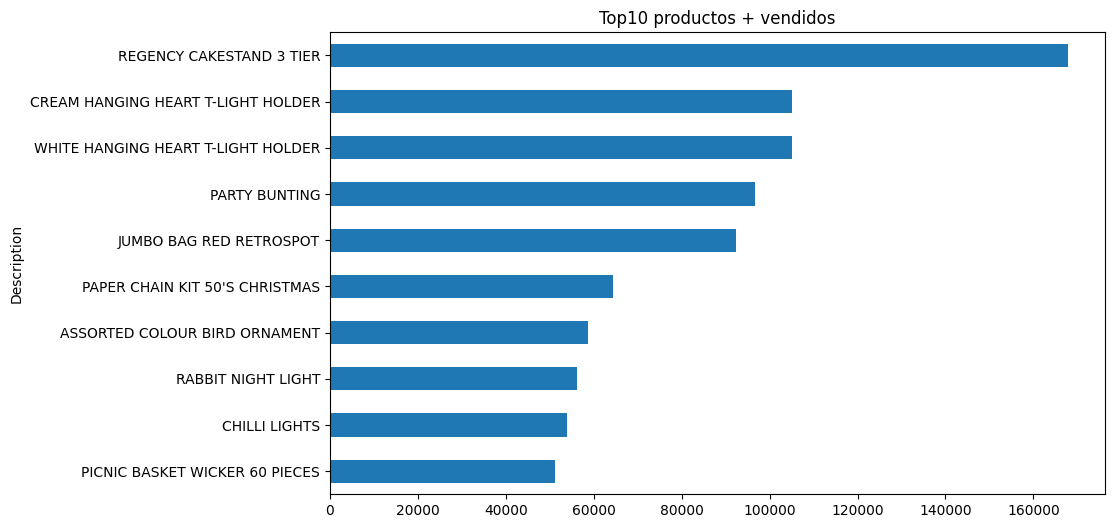

In [ ]:
excluir = ["DOTCOM POSTAGE", "Manual", "POSTAGE", "CRUK Commission"]

df_merge = df_ventas.merge(df_productos[["StockCode", "Description"]],
                            on="StockCode", how="left")

top_productos = (df_merge[~df_merge["Description"].isin(excluir)]
                 .groupby("Description")["TotalSales"]
                 .sum()
                 .sort_values(ascending=False)
                 .head(10))

top_productos.plot(kind="barh", figsize=(10,6),
                   title="Top10 productos + vendidos")
plt.gca().invert_yaxis()
plt.show()

### **Agregación semanal por país**

Agrupamos las ventas a nivel semanal por país. Esta granularidad nos permite capturar la estacionalidad sin el ruido diario, y es la base sobre la que construiremos los modelos.

In [ ]:
df_ventas["YearWeek"] = df_ventas["Date"].dt.to_period("W")

df_ventas_semanal = (df_ventas
                        .groupby(["YearWeek", "Country"])["TotalSales"]
                        .sum()
                        .reset_index())

In [ ]:
df_ventas_semanal.head(20)

,YearWeek,Country,TotalSales
0,2022-11-28/2022-12-04,Belgium,304.90
1,2022-11-28/2022-12-04,France,1164.30
2,2022-11-28/2022-12-04,Germany,882.66
3,2022-11-28/2022-12-04,Ireland,2847.82
4,2022-11-28/2022-12-04,Italy,354.70
5,2022-11-28/2022-12-04,Netherlands,177.60
6,2022-11-28/2022-12-04,Portugal,101.80
7,2022-11-28/2022-12-04,Spain,521.00
8,2022-11-28/2022-12-04,United Kingdom,140426.68
9,2022-12-05/2022-12-11,France,5582.57


In [ ]:
df_ventas_semanal.groupby("Country")["TotalSales"].count().sort_values(ascending=False)

,TotalSales
Country,
France,53
Germany,53
United Kingdom,53
Ireland,50
Belgium,47
Spain,45
Netherlands,35
Portugal,33
Sweden,28


In [ ]:
df_ventas_semanal.columns = ["ds", "Country", "y"]
df_ventas_semanal["ds"] = df_ventas_semanal["ds"].dt.to_timestamp()
df_ventas_semanal["ds"] = pd.to_datetime(df_ventas_semanal["ds"].dt.date)
df_ventas_semanal.head()

,ds,Country,y
0,2022-11-28,Belgium,304.90
1,2022-11-28,France,1164.30
2,2022-11-28,Germany,882.66
3,2022-11-28,Ireland,2847.82
4,2022-11-28,Italy,354.70


In [ ]:
fig = px.line(df_ventas_semanal, x="ds", y="y", color="Country",
              title="Ventas semanales por país")
fig.show()

Vamos a agrupar **países con ventas similares** para poder visualizarlo mejor:

In [ ]:
grupos = [["United Kingdom"],
          ["Netherlands", "Ireland", "France", "Germany"],
          ["Belgium", "Spain", "Portugal", "Italy", "Sweden"]]

for grupo in grupos:
    fig = px.line(df_ventas_semanal[df_ventas_semanal["Country"].isin(grupo)],
                  x="ds", y="y", color="Country",
                  title=f"Ventas semanales - {', '.join(grupo)}")
    fig.show()

En las gráficas hemos podido comprobar que **United Kingdom domina las ventas** con valores
muy por encima del resto.

En los países secundarios se aprecian **picos puntuales e irregulares**, lo que es normal en **mercados con menor volumen y mayor volatilidad semanal**.

El **pico de noviembre** (posiblemente impulsado por el Black Friday y las fechas prenavideñas) es visible en la mayoría de países.

# **2. Serie Temporal: UK**

**United Kingdom** representa el **93% de las ventas totales de TodoVentas S.A**,
por lo que en un principio vamos a centrar nuestro análisis en este mercado.

## **Análisis**

### **Ventas diarias**

In [ ]:
df_uk_daily = df_ventas[df_ventas["Country"] == "United Kingdom"].groupby("Date")["TotalSales"].sum().reset_index()
df_uk_daily.columns = ["ds", "y"]
df_uk_daily["ds"] = pd.to_datetime(df_uk_daily["ds"])

all_dates = pd.DataFrame(pd.date_range(df_uk_daily["ds"].min(), df_uk_daily["ds"].max(), freq="D"), columns=["ds"])
df_uk_daily_full = all_dates.merge(df_uk_daily, on="ds", how="left")
df_uk_daily_full["tiene_ventas"] = df_uk_daily_full["y"].notna().astype(int)

fig = px.bar(df_uk_daily_full, x="ds", y="y",
             title="Ventas diarias en UK",
             labels={"y": "Ventas", "ds": "Fecha"},
             color_discrete_sequence=["steelblue"])
fig.show()

Visualizamos las ventas diarias a lo largo de todo el año para identificar días sin actividad:

* Los **domingos no hay ventas**
* **Cierre en Navidad/Año nuevo** (24 Diciembre - 3 Enero)

Por ello trabajaremos con **agregación semanal**, **eliminando la última semana de diciembre 2023 (incompleta)**
y **rellenando la semana de cierre navideño con 1** para poder reflejar así la realidad de la
empresa sin distorsionar los modelos.

El estudio se hará sobre las **53 semanas (diciembre 2022 - noviembre 2023)**

In [ ]:
df_uk = df_ventas_semanal[df_ventas_semanal["Country"] == "United Kingdom"].copy()
df_uk = df_uk[["ds", "y"]]

df_uk = df_uk[df_uk["ds"] < "2023-12-04"]                                         # Eliminamos semana incompleta

full_idx = pd.date_range(df_uk["ds"].min(), df_uk["ds"].max(), freq="W-MON")
df_uk = df_uk.set_index("ds").reindex(full_idx).fillna(1).reset_index()           # Rellenamos cierre navideño

df_uk.columns = ["ds", "y"]

df_uk.head(10)

,ds,y
0,2022-11-28,140426.68
1,2022-12-05,309122.21
2,2022-12-12,199583.32
3,2022-12-19,81449.97
4,2022-12-26,1.00
5,2023-01-02,99474.49
6,2023-01-09,150797.46
7,2023-01-16,98830.28
8,2023-01-23,98245.78
9,2023-01-30,109545.24


### **Evolución temporal**
A continuación analizamos la **evolución de las ventas semanales en United Kingdom**.

La **línea de media móvil** suaviza las variaciones puntuales y nos ayuda a ver
la **tendencia general positiva** del negocio a lo largo del año.

In [ ]:
df_uk["media_movil"] = df_uk["y"].rolling(window=4, min_periods=1).mean()         # Media móvil de 4 semanas

fig = px.line(df_uk, x="ds", y=["y", "media_movil"],
              title="Ventas semanales UK + Media Móvil")
fig.show()

El **histograma** muestra la **distribución de ventas semanales**.

La mayoría de semanas tienen ventas entre **100k y 200k**.

Luego también tenemos **semanas por encima de 250k** correspondientes
a los picos de ventas que hemos visto antes.

In [ ]:
px.histogram(df_uk["y"], title="Distribución de ventas semanales UK")

Ahora vamos a mirar la **variación en las ventas semanales** a lo largo del año.

In [ ]:
df_uk["diferencia"] = df_uk["y"].diff(1)

fig = px.bar(df_uk.dropna(subset=["diferencia"]), x="ds", y="diferencia",
             title="Variación semanal de ventas - UK")
fig.show()

Se observan **grandes caídas en diciembre**, probablemente por la corrección tras el pico del Black Friday de Noviembre.

El resto del año muestra subidas y bajadas semanales que **analizaremos posteriormente**.

### **Descomposición de la serie**
Vamos a descomponer la serie en sus componentes principales: **tendencia, estacionalidad y residuos**.

Como solo **disponemos de 53 semanas** de datos usaremos **period=26 (mitad del año)**

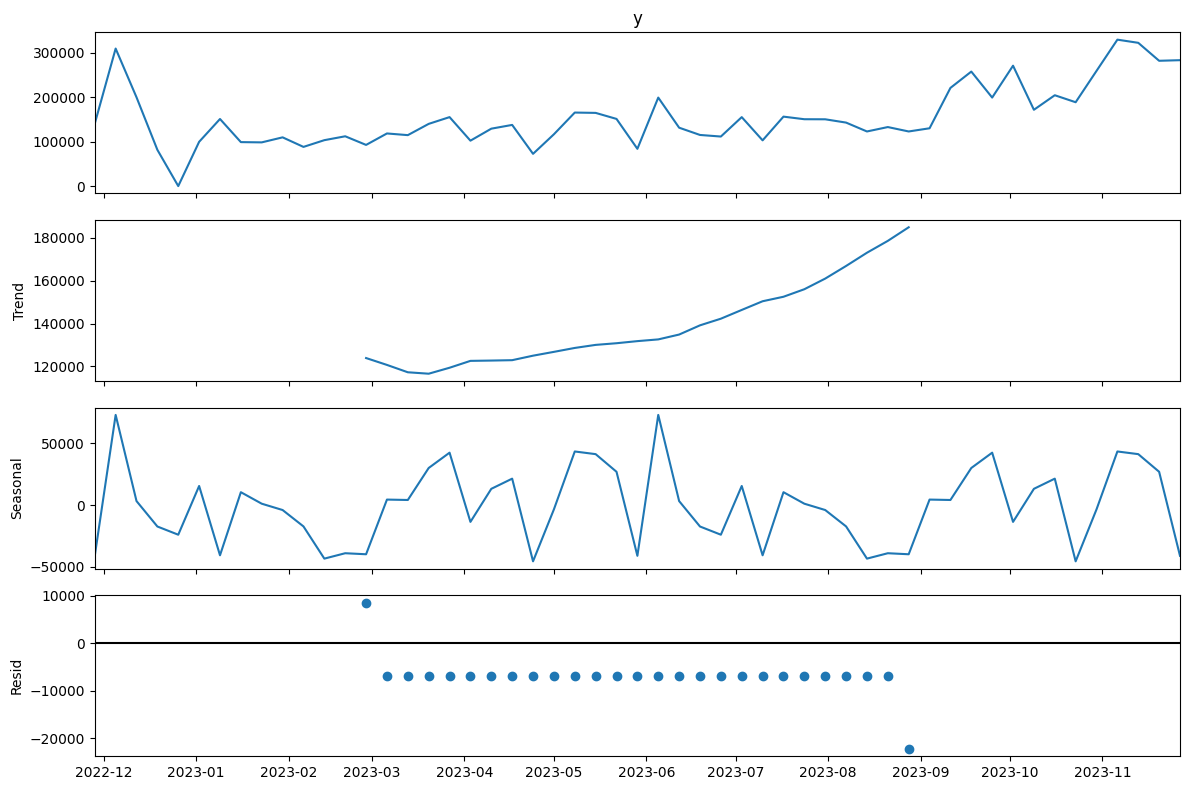

In [ ]:
serie_uk = df_uk.set_index("ds")["y"]

result_add = seasonal_decompose(serie_uk, model="additive", period=26)   # DESCOMPOSICIÓN ADITIVA
result_add.plot()
plt.gcf().set_size_inches(12, 8)
plt.tight_layout()
plt.show()

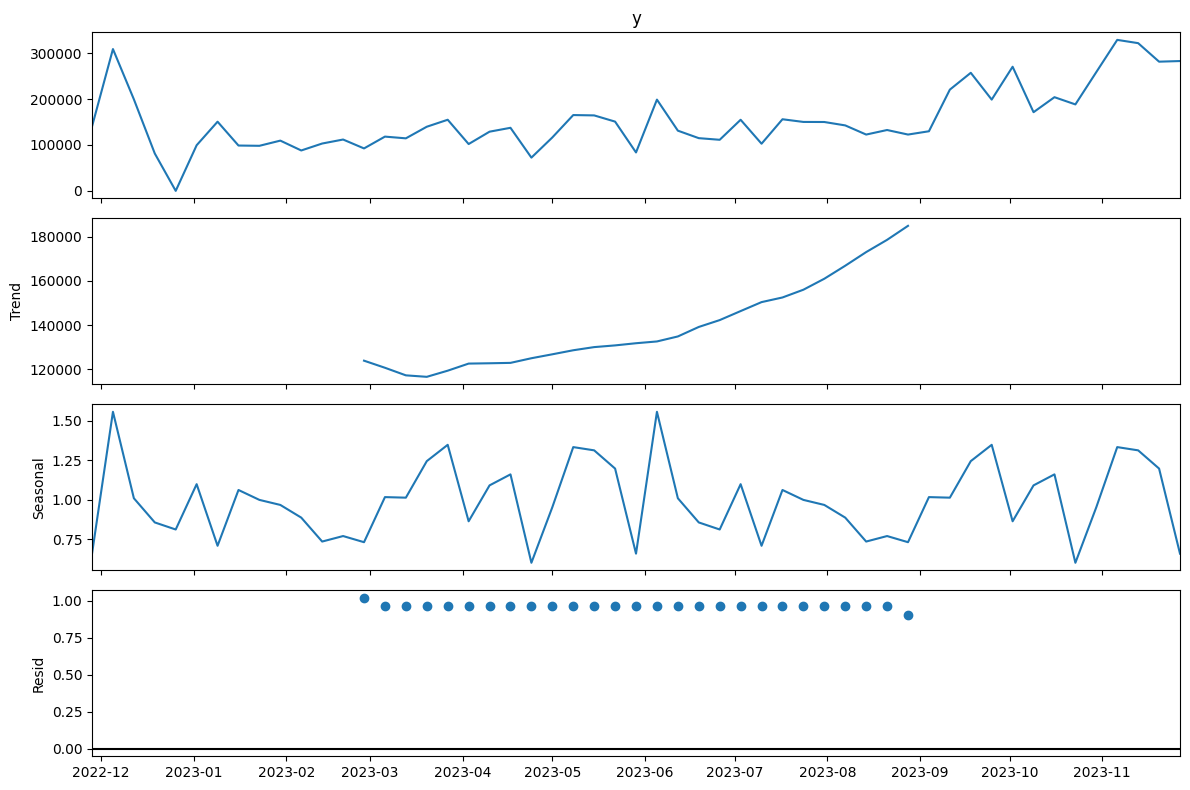

In [ ]:
result_mult = seasonal_decompose(serie_uk, model="multiplicative", period=26)    # DESCOMPOSICIÓN MULTIPLICATIVA
result_mult.plot()
plt.gcf().set_size_inches(12, 8)
plt.tight_layout()
plt.show()

Ambas descomposiciones muestran resultados muy similares:
    
* La **tendencia** es **ascendente** a lo largo del año.
* La **estacionalidad** muestra un **patrón semestral** con picos en verano y fin de año.
* Los **residuos** representan lo que **no pueden explicar la tendencia ni la
estacionalidad.**

In [ ]:
# GUARDAMOS LAS COMPONENTES TEMPORALES:
df_uk["observed"] = result_mult.observed.reset_index(drop=True)
df_uk["trend"] = result_mult.trend.reset_index(drop=True)
df_uk["seasonal"] = result_mult.seasonal.reset_index(drop=True)
df_uk["resid"] = result_mult.resid.reset_index(drop=True)

df_uk.head()

,ds,y,media_movil,diferencia,observed,trend,seasonal,resid
0,2022-11-28,140426.68,140426.68,NaN,140426.68,NaN,0.66,NaN
1,2022-12-05,309122.21,224774.45,168695.53,309122.21,NaN,1.56,NaN
2,2022-12-12,199583.32,216377.40,-109538.89,199583.32,NaN,1.01,NaN
3,2022-12-19,81449.97,182645.55,-118133.35,81449.97,NaN,0.86,NaN
4,2022-12-26,1.00,147539.12,-81448.97,1.00,NaN,0.81,NaN


### **Estacionariedad - Test ADF**

Una serie es **estacionaria** cuando su **media y varianza son constantes en el tiempo**.

Vamos a comprobar si nuestra serie es estacionaria con el **test de Dickey-Fuller:**
* *p-value ≤ 0.05 -> ***ESTACIONARIA****
* *p-value > 0.05 -> ***NO ESTACIONARIA****

In [ ]:
result_adf = adfuller(df_uk["y"])
print(f"p-value: {result_adf[1]:.4f}")

if result_adf[1] <= 0.05:
    print("La serie SI es estacionaria ✅ ")
else:
    print("La serie NO es estacionaria ❌ ")

p-value: 0.9554
La serie NO es estacionaria ❌ 


La serie de **ventas semanales** de Reino Unido **NO es estacionaria**,
lo cual es común en series temporales de ventas.

Además antes hemos visto en las gráficas que había una clara **tendencia creciente** lo que implica
que la **media de las ventas no es constante en el tiempo**.

### **ACF y PACF**

* La **Autocorrelación (ACF)** mide la correlación de la serie **con sus propios valores pasados (lags)**.

* La **Autocorrelación Parcial (PACF)** mide la misma correlación pero **eliminando el efecto de los lags intermedios**.

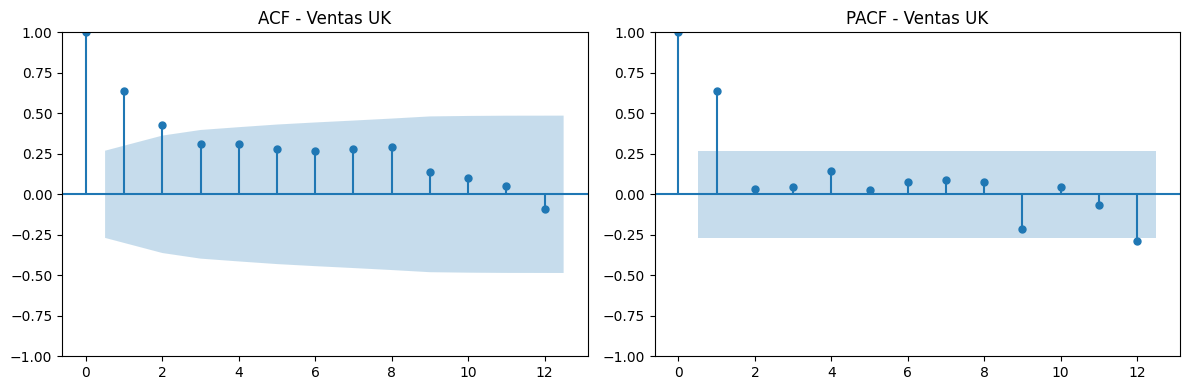

In [ ]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

plot_acf(df_uk["y"], lags=12, ax=axes[0], title="ACF - Ventas UK")
plot_pacf(df_uk["y"], lags=12, ax=axes[1], title="PACF - Ventas UK")

plt.tight_layout()
plt.show()

* El **ACF** muestra **correlación significativa en los lags 1 y 2**,
que va decayendo gradualmente
* El **PACF** muestra **correlación directa relevante en el lag 1 (semana anterior)**
  y una **correlación negativa en el lag 12** (trimestre anterior)

## **Modelos**

Para evaluar los modelos usamos las **últimas 4 semanas de noviembre 2023 como test**, entrenando con las 49 semanas anteriores.

El objetivo final es predecir las **4 semanas de diciembre 2023** y sumarlas para obtener el total mensual.

In [ ]:
df_train = df_uk[df_uk["ds"] < "2023-11-01"].copy()   # Train: dic 2022 - oct 2023
df_test  = df_uk[df_uk["ds"] >= "2023-11-01"].copy()  # Test: nov 2023

print(f"Train: {len(df_train)} semanas")
print(f"Test:  {len(df_test)} semanas")

Train: 49 semanas
Test:  4 semanas


### **Prophet**

**Prophet** es la librería de Meta para predicción de series temporales. Es especialmente útil cuando hay tendencia y estacionalidad claras, y permite incorporar eventos externos como festivos.

In [ ]:
df_train_prophet = df_train[["ds", "y"]].copy()
df_test_prophet  = df_test[["ds", "y"]].copy()


m = Prophet(seasonality_mode='multiplicative',    # Ajustes del modelo
            weekly_seasonality=False,
            daily_seasonality=False)
m.fit(df_train_prophet)

INFO:prophet:Disabling yearly seasonality. Run prophet with yearly_seasonality=True to override this.


In [ ]:
future = m.make_future_dataframe(periods=4, freq='W')          # Proyectamos 4 semanas hacia adelante (nov 2023)
forecast = m.predict(future)

forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].tail(6)   # Predicciones

,ds,yhat,yhat_lower,yhat_upper
47,2023-10-23,182501.66,122410.97,246945.86
48,2023-10-30,184200.83,119154.59,249711.87
49,2023-11-05,185657.25,121926.58,252937.71
50,2023-11-12,187356.42,122954.09,255845.87
51,2023-11-19,189055.58,125126.46,254661.77
52,2023-11-26,190754.74,127159.59,255379.43


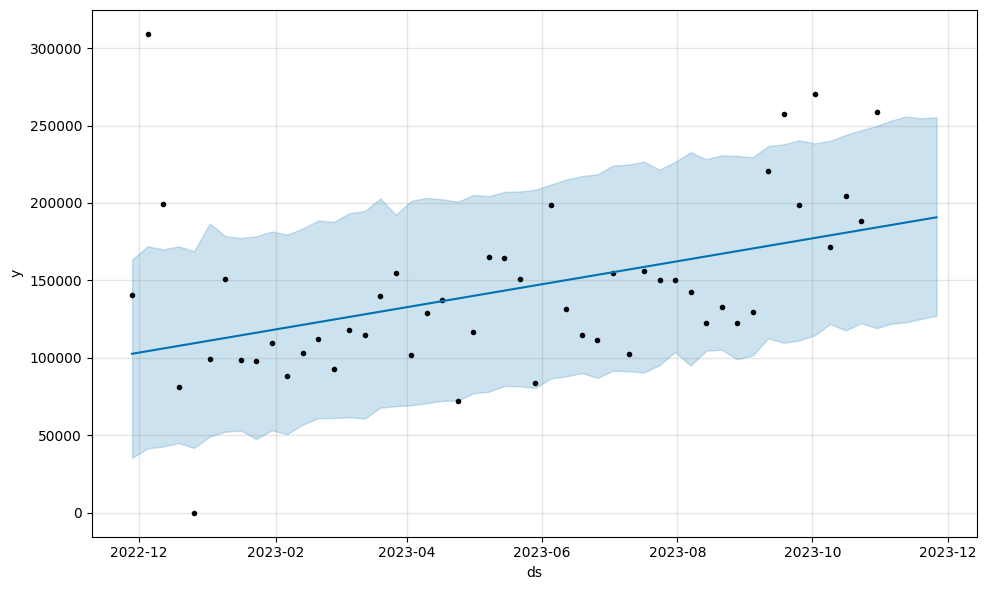

In [ ]:
plot(m, forecast)
plt.show()

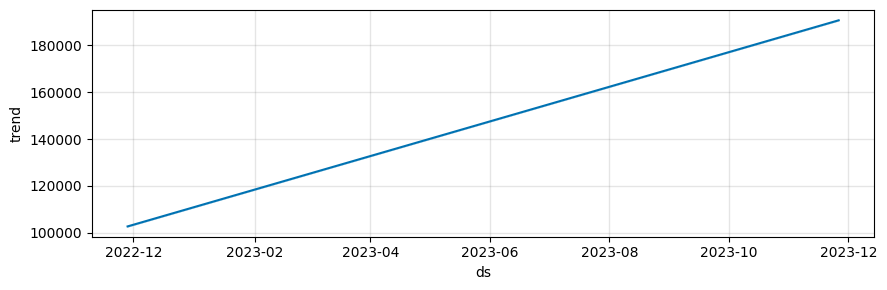

In [ ]:
plot_components(m, forecast)
plt.show()

In [ ]:
df_plot = pd.concat([
    df_train_prophet.set_index("ds")["y"].rename("Real"),
    forecast.set_index("ds")["yhat"].rename("Predicción Prophet")
], axis=1)

px.line(df_plot, title="Prophet UK: Real vs Predicción")

In [ ]:
y_real_nov = df_test["y"].values
y_pred_nov = forecast.tail(4)["yhat"].values

rmse_prophet = sqrt(mean_squared_error(y_real_nov, y_pred_nov))
mape_prophet = mean_absolute_percentage_error(y_real_nov, y_pred_nov) * 100

print(f"RMSE Prophet:  {rmse_prophet:,.0f}")
print(f"MAPE Prophet:  {round(mape_prophet, 2)}%")

RMSE Prophet:  118,111
MAPE Prophet:  37.72%


Prophet captura la tendencia ascendente pero falla en los picos semanales por falta de histórico suficiente para aprender la estacionalidad anual.

### **SARIMAX**

SARIMAX es el **modelo clásico de series temporales** que combina **autorregresión**,
**diferenciación** y **medias móviles** con la componente estacional.

Vamos a usar `auto_arima` para encontrar automáticamente los mejores parámetros -> ***(p, d, q) (P, D, Q)***

* **p** = número de valores pasados (autorregresión)
* **d** = número de diferenciaciones para hacer la serie estacionaria
* **q** = número de errores pasados (media móvil)
* **(P,D,Q) m** = los mismos componentes pero a nivel estacional, donde m es el periodo

SARIMAX requiere que la serie sea **estacionaria**. Al haber comprobado
que la nuestra **NO lo es**, `auto_arima` aplicará automáticamente
las diferenciaciones necesarias mediante el parámetro **d** para que sea estacionaria.

In [ ]:
auto_model = auto_arima(df_train["y"],
                        start_p=0, start_q=0,
                        max_p=3, max_q=3,
                        m=52,
                        seasonal=True,
                        D=0, max_d=3,
                        trace=True,
                        error_action="ignore",
                        suppress_warnings=True)

print(auto_model.summary())

Performing stepwise search to minimize aic
 ARIMA(0,1,0)(1,0,1)[52] intercept   : AIC=1195.576, Time=0.08 sec
 ARIMA(0,1,0)(0,0,0)[52] intercept   : AIC=1191.576, Time=0.01 sec
 ARIMA(1,1,0)(1,0,0)[52] intercept   : AIC=1195.278, Time=0.43 sec
 ARIMA(0,1,1)(0,0,1)[52] intercept   : AIC=inf, Time=0.84 sec
 ARIMA(0,1,0)(0,0,0)[52]             : AIC=1189.676, Time=0.01 sec
 ARIMA(0,1,0)(1,0,0)[52] intercept   : AIC=1193.576, Time=0.06 sec
 ARIMA(0,1,0)(0,0,1)[52] intercept   : AIC=1193.576, Time=0.06 sec
 ARIMA(1,1,0)(0,0,0)[52] intercept   : AIC=1195.010, Time=0.02 sec
 ARIMA(0,1,1)(0,0,0)[52] intercept   : AIC=1197.700, Time=0.01 sec
 ARIMA(1,1,1)(0,0,0)[52] intercept   : AIC=1195.444, Time=0.03 sec

Best model:  ARIMA(0,1,0)(0,0,0)[52]          
Total fit time: 1.562 seconds
                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                   49
Model:               SARIMAX(0, 1, 0)   Log Likelihood  

* `auto_arima` ha seleccionado **ARIMA(0,1,0)(0,0,0)[52]** como modelo óptimo

* El **parámetro d=1** indica que aplica una diferenciación para hacer la serie estacionaria

In [ ]:
df_train_sarimax = df_train[["ds", "y"]].copy()
df_train_sarimax = df_train_sarimax.set_index("ds")

full_idx = pd.date_range(df_train_sarimax.index.min(), df_train_sarimax.index.max(), freq="W-MON")
df_train_sarimax = df_train_sarimax.reindex(full_idx, fill_value=1)

model_sarimax = SARIMAX(df_train_sarimax["y"],
                        order=(0,1,0),
                        seasonal_order=(0,0,0,52))
results_sarimax = model_sarimax.fit(disp=False)
print(results_sarimax.summary())

                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                   49
Model:               SARIMAX(0, 1, 0)   Log Likelihood                -593.838
Date:                Thu, 16 Apr 2026   AIC                           1189.676
Time:                        12:35:27   BIC                           1191.547
Sample:                    11-28-2022   HQIC                          1190.383
                         - 10-30-2023                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
sigma2      3.194e+09   5.66e+08      5.641      0.000    2.08e+09     4.3e+09
Ljung-Box (L1) (Q):                   3.18   Jarque-Bera (JB):                 1.04
Prob(Q):                              0.07   Pr

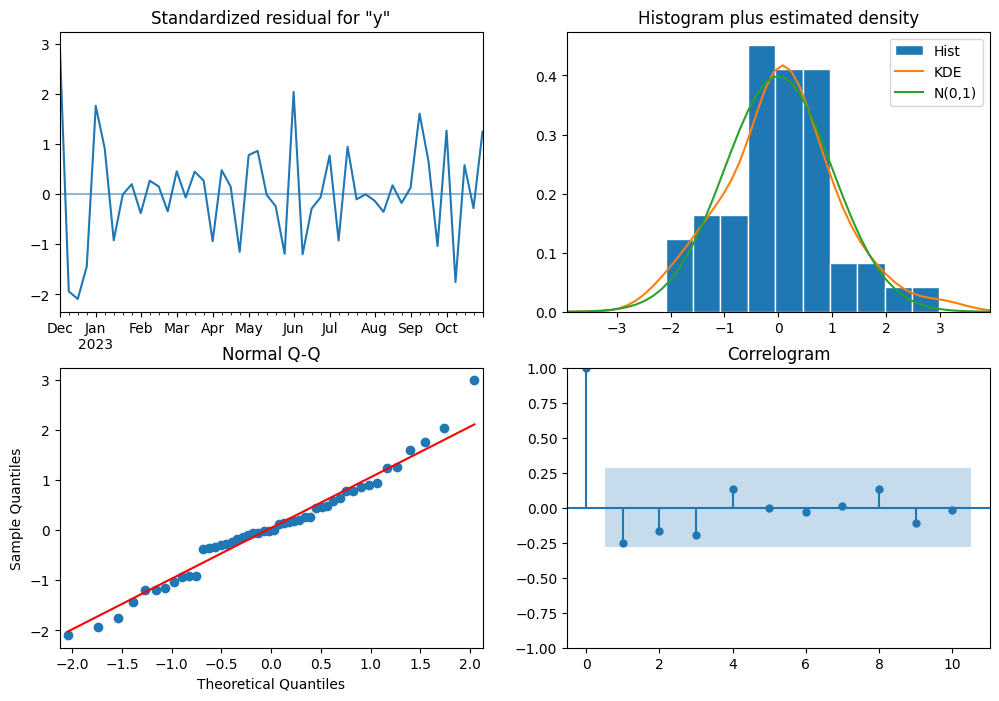

In [ ]:
results_sarimax.plot_diagnostics(figsize=(12, 8))
plt.show()

Los 4 gráficos analizan los **residuos del modelo desde distintas perspectivas**, para así confirmar que el ajuste es correcto:

1-  **Residuos estandarizados ->** fluctúan alrededor de 0 sin patrón claro

2-  **Histograma ->** distribución aproximadamente normal centrada en 0

3-  **Q-Q Plot   ->** los puntos siguen la línea roja

4-  **Correlogram ->** no hay autocorrelación significativa en los residuos

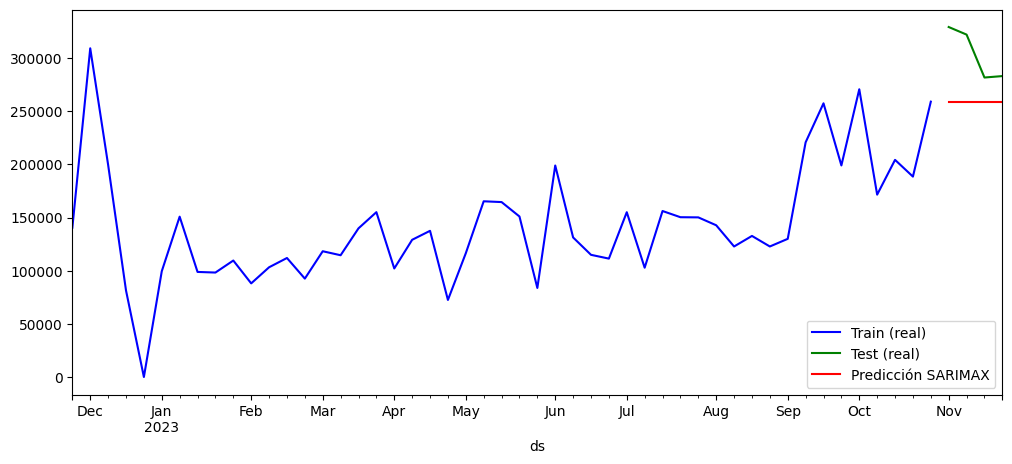

In [ ]:
forecast_sarimax = results_sarimax.predict(
    start=len(df_train_sarimax),
    end=len(df_train_sarimax) + 3,
    typ='levels'
).rename('Predicción SARIMAX')

df_train_sarimax["y"].plot(figsize=(12,5), label="Train (real)", color="blue", legend=True)
df_test.set_index("ds")["y"].plot(label="Test (real)", color="green", legend=True)
forecast_sarimax.plot(label="Predicción SARIMAX", color="red", legend=True)
plt.show()

In [ ]:
y_real_nov = df_test["y"].values
y_pred_sarimax = forecast_sarimax.values

rmse_sarimax = sqrt(mean_squared_error(y_real_nov, y_pred_sarimax))
mape_sarimax = mean_absolute_percentage_error(y_real_nov, y_pred_sarimax) * 100

print(f"RMSE SARIMAX:  {rmse_sarimax:,.0f}")
print(f"MAPE SARIMAX:  {round(mape_sarimax, 2)}%")

RMSE SARIMAX:  49,995
MAPE SARIMAX:  14.37%


SARIMAX mejora el MAPE respecto a Prophet, pero su predicción es una línea constante porque **ARIMA(0,1,0)** es un random walk — con solo un año de histórico no encuentra patrones suficientes para predecir variaciones semanales.

### **XGBoost**

**XGBoost** es un algoritmo de Machine Learning basado en árboles de decisión con boosting. A diferencia de Prophet y SARIMAX, no trabaja nativamente con series temporales, por lo que usamos la librería **sktime** para adaptarlo a la predicción de series mediante una estrategia recursiva.

In [ ]:
df_xgb = df_uk[["ds", "y"]].copy()
df_xgb = df_xgb.set_index("ds")
df_xgb.index = pd.DatetimeIndex(df_xgb.index).to_period("W-MON")

y_train_xgb = df_xgb.iloc[:-4]["y"]
y_test_xgb  = df_xgb.iloc[-4:]["y"]

fh = ForecastingHorizon(y_test_xgb.index, is_relative=False)

print(f"Train: {len(y_train_xgb)} semanas")
print(f"Test:  {len(y_test_xgb)} semanas")

Train: 49 semanas
Test:  4 semanas


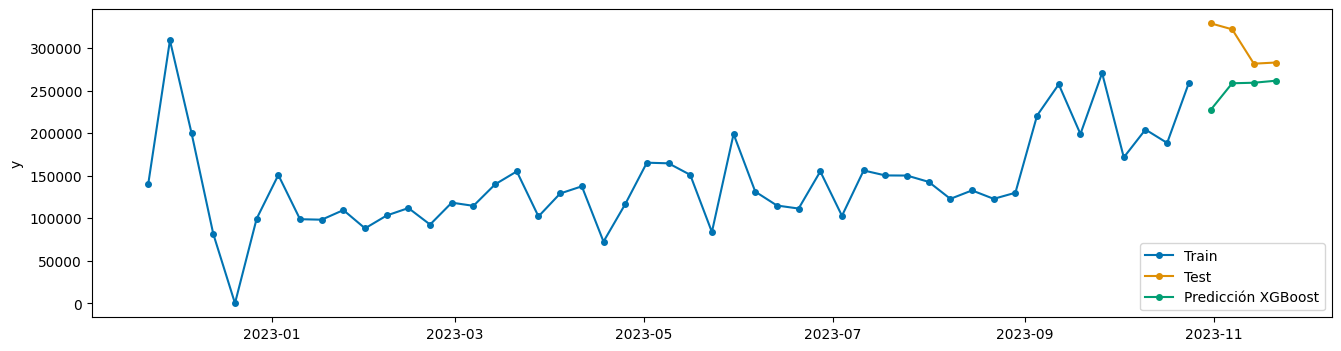

In [ ]:
xgb_regressor = XGBRegressor(objective='reg:squarederror', random_state=42)
forecaster_xgb = make_reduction(xgb_regressor, strategy="recursive")
forecaster_xgb.fit(y_train_xgb)
y_pred_xgb = forecaster_xgb.predict(fh)

plot_series(y_train_xgb, y_test_xgb, y_pred_xgb,
            labels=["Train", "Test", "Predicción XGBoost"])
plt.show()

In [ ]:
mape_xgb = mape_sktime(y_test_xgb, y_pred_xgb, symmetric=False)
rmse_xgb = sqrt(mean_squared_error(y_test_xgb, y_pred_xgb))

print(f"RMSE XGBoost:  {rmse_xgb:,.0f}")
print(f"MAPE XGBoost:  {round(mape_xgb * 100, 2)}%")

RMSE XGBoost:  62,046
MAPE XGBoost:  16.55%


XGBoost captura mejor la tendencia ascendente y la variabilidad semanal que los modelos anteriores.

### **Comparativa**

|    Modelo    | RMSE    | MAPE   |
|--------------|---------|--------|
| **Prophet**  | 118,111 | 37.72% |
| **SARIMAX**  | 49,995  | 14.37% |
| **XGBoost**  | 62,046  | 16.55% |

**SARIMAX obtiene el mejor resultado en esta fase baseline, seguido de cerca por XGBoost. Prophet queda muy por detrás con un 37% de error**.


En la siguiente sección añadimos variables exógenas para intentar mejorar estas predicciones.

Dado el bajo rendimiento de Prophet, **nos vamos a centrar únicamente en SARIMAX y XGBoost**, donde hay más margen de mejora.

## **Variables Exógenas**

Añadimos variables que recogen eventos conocidos que afectan las ventas en UK:
* **Festivos oficiales UK** → número de días festivos en esa semana
* **Temporada navideña** → semanas de diciembre (pico de compras)
* **Cierre navideño** → empresa cerrada
* **Black Friday** → semana de máximas ventas del año

In [ ]:
import holidays

uk_holidays = holidays.UK(years=[2022, 2023])


def get_exog_features(dates):
    df_exog = pd.DataFrame({"ds": dates})

    df_exog["n_festivos"] = df_exog["ds"].apply(
        lambda x: sum(1 for d in pd.date_range(x, periods=7) if d in uk_holidays)
    )
    df_exog["temporada_navidad"] = df_exog["ds"].apply(
        lambda x: 1 if x.month == 12 else 0
    )
    df_exog["cierre_navidad"] = df_exog["ds"].apply(
        lambda x: 1 if (x.month == 1 and 1 <= x.day <= 9)
                    or (x.month == 12 and x.day >= 24) else 0
    )

    black_fridays = [pd.Timestamp('2022-11-25'), pd.Timestamp('2023-11-24')]
    df_exog["black_friday"] = 0
    for bf in black_fridays:
        semanas = df_exog["ds"][df_exog["ds"] >= bf]
        if len(semanas) > 0:
            df_exog.loc[semanas.index[0], "black_friday"] = 1

    return df_exog.set_index("ds")

In [ ]:
X_train = get_exog_features(df_train["ds"])
X_test  = get_exog_features(df_test["ds"])

X_train.head(10)

,n_festivos,temporada_navidad,cierre_navidad,black_friday
ds,,,,
2022-11-28,0,0,0,1
2022-12-05,0,1,0,0
2022-12-12,0,1,0,0
2022-12-19,1,1,0,0
2022-12-26,3,1,1,0
2023-01-02,1,0,1,0
2023-01-09,0,0,1,0
2023-01-16,0,0,0,0
2023-01-23,0,0,0,0


### **SARIMAX**

In [ ]:
df_train_sarimax_exog = df_train[["ds", "y"]].copy().set_index("ds")
full_idx = pd.date_range(df_train_sarimax_exog.index.min(),
                         df_train_sarimax_exog.index.max(), freq="W-MON")
df_train_sarimax_exog = df_train_sarimax_exog.reindex(full_idx, fill_value=1)
X_train_s = X_train.reindex(full_idx, fill_value=0)

model_sarimax_exog = SARIMAX(df_train_sarimax_exog["y"],
                              order=(0,1,0),
                              seasonal_order=(0,0,0,52),
                              exog=X_train_s)
results_sarimax_exog = model_sarimax_exog.fit(disp=False)
print(results_sarimax_exog.summary())

                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                   49
Model:               SARIMAX(0, 1, 0)   Log Likelihood                -650.129
Date:                Thu, 16 Apr 2026   AIC                           1310.258
Time:                        12:35:29   BIC                           1319.614
Sample:                    11-28-2022   HQIC                          1313.794
                         - 10-30-2023                                         
Covariance Type:                  opg                                         
                        coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------
n_festivos        -5.205e+04   6.16e+05     -0.085      0.933   -1.26e+06    1.16e+06
temporada_navidad  4628.6240      0.050    9.2e+04      0.000    4628.525    4628.723
cierre_navidad     3.731

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/representation.py:374: FutureWarning:

Unknown keyword arguments: dict_keys(['typ']).Passing unknown keyword arguments will raise a TypeError beginning in version 0.15.



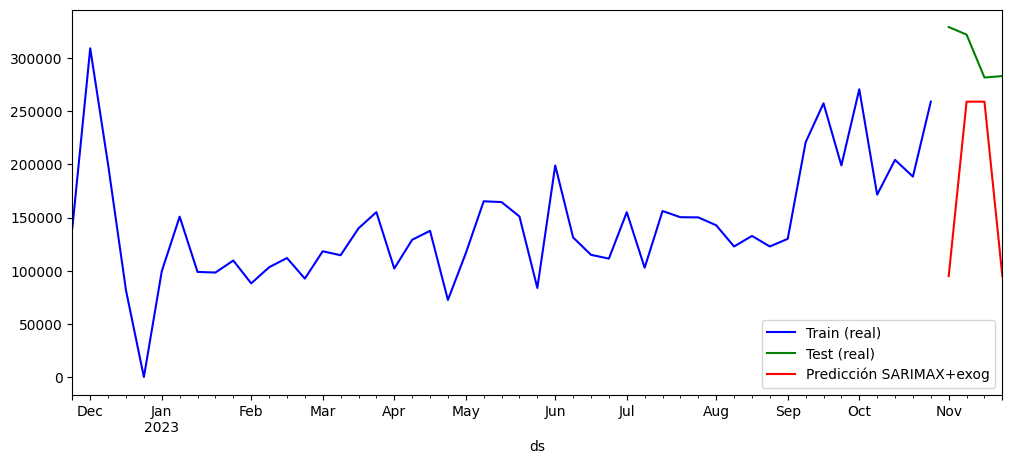

In [ ]:
forecast_sarimax_exog = results_sarimax_exog.predict(
    start=len(df_train_sarimax_exog),
    end=len(df_train_sarimax_exog) + 3,
    exog=X_test,
    typ='levels'
)

df_train_sarimax_exog["y"].plot(figsize=(12,5), label="Train (real)", color="blue", legend=True)
df_test.set_index("ds")["y"].plot(label="Test (real)", color="green", legend=True)
forecast_sarimax_exog.plot(label="Predicción SARIMAX+exog", color="red", legend=True)
plt.show()

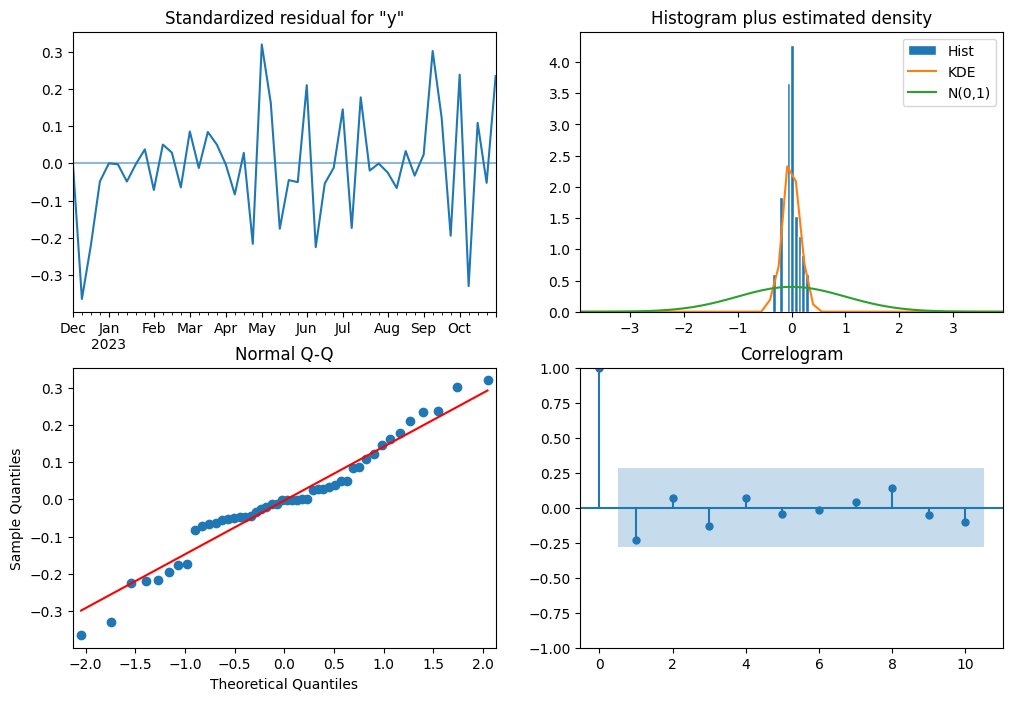

In [ ]:
results_sarimax_exog.plot_diagnostics(figsize=(12, 8))
plt.show()

In [ ]:
y_real_nov = df_test["y"].values
y_pred_sarimax_exog = forecast_sarimax_exog.values

rmse_sarimax_exog = sqrt(mean_squared_error(y_real_nov, y_pred_sarimax_exog))
mape_sarimax_exog = mean_absolute_percentage_error(y_real_nov, y_pred_sarimax_exog) * 100

print(f"RMSE SARIMAX + variables exog:  {rmse_sarimax_exog:,.0f}")
print(f"MAPE SARIMAX + variables exog:  {round(mape_sarimax_exog, 2)}%")

RMSE SARIMAX + variables exog:  153,914
MAPE SARIMAX + variables exog:  41.32%


Con variables exógenas SARIMAX deja de ser una línea constante — el Black Friday le indica que esa semana es especial y ajusta la predicción. Sin embargo, el MAPE empeora significativamente (de 14.37% a 41.32%) porque con un solo año de datos el modelo no tiene suficiente contexto para aprender bien la magnitud del pico.

### **XGBoost**

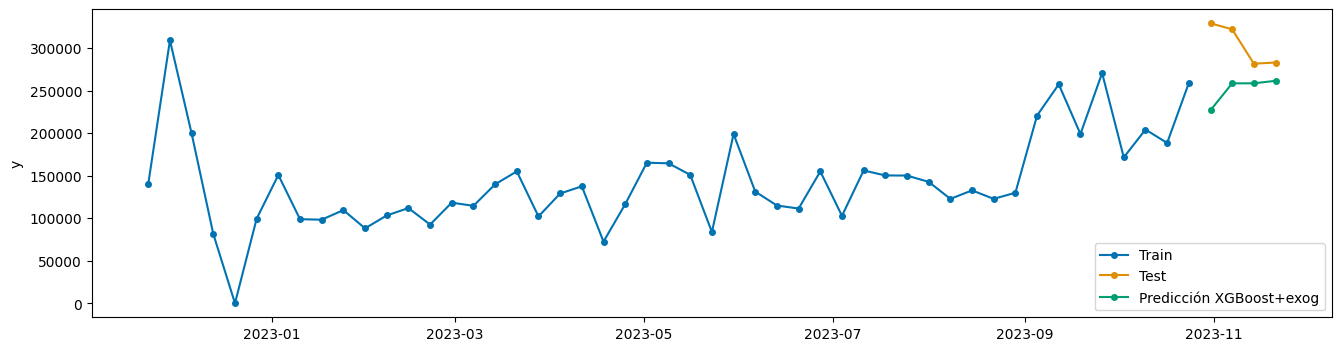

In [ ]:
# Alineamos índices de exógenas con sktime
X_train_xgb = X_train.copy()
X_train_xgb.index = y_train_xgb.index
X_test_xgb = X_test.copy()
X_test_xgb.index = y_test_xgb.index

xgb_regressor = XGBRegressor(objective='reg:squarederror', random_state=42)
forecaster_xgb_exog = make_reduction(xgb_regressor, strategy="recursive")

forecaster_xgb_exog.fit(y_train_xgb, X=X_train_xgb)
y_pred_xgb_exog = forecaster_xgb_exog.predict(fh, X=X_test_xgb)

plot_series(y_train_xgb, y_test_xgb, y_pred_xgb_exog,
            labels=["Train", "Test", "Predicción XGBoost+exog"])
plt.show()

In [ ]:
mape_xgb_exog = mape_sktime(y_test_xgb, y_pred_xgb_exog, symmetric=False)
rmse_xgb_exog = sqrt(mean_squared_error(y_test_xgb, y_pred_xgb_exog))

print(f"RMSE XGBoost + variables exog:  {rmse_xgb_exog:,.0f}")
print(f"MAPE XGBoost + variables exog:  {round(mape_xgb_exog * 100, 2)}%")
print(f"\nMejora RMSE: {rmse_xgb - rmse_xgb_exog:,.0f}")
print(f"Mejora MAPE: {round((mape_xgb - mape_xgb_exog) * 100, 2)}pp")

RMSE XGBoost + variables exog:  62,195
MAPE XGBoost + variables exog:  16.64%

Mejora RMSE: -149
Mejora MAPE: -0.08pp


En ninguno de los dos modelos las variables exógenas consiguen mejorar los resultados:

* **SARIMAX** reacciona al Black Friday pero lo sobreestima — sin suficiente histórico no puede calibrar bien la magnitud del evento.
* **XGBoost** apenas cambia (+0.08pp de MAPE) porque los lags ya capturan implícitamente la información reciente, y el Black Friday como variable explícita no añade nada nuevo.

## **Predicción Diciembre 2023**

Entrenamos el modelo con **todos los datos disponibles (diciembre 2022 - noviembre 2023)** y **predecimos las 4 semanas de diciembre 2023.**

Usamos **XGBoost** como modelo final — aunque SARIMAX obtuvo mejor MAPE en el baseline, XGBoost genera predicciones más realistas semana a semana y es más robusto ante la variabilidad del periodo navideño.

In [ ]:
df_full = df_uk[df_uk["ds"] < "2023-12-04"].copy()

future_dates = pd.date_range("2023-12-04", periods=4, freq="W-MON")
print("Semanas a predecir:")
for d in future_dates:
    print(f"  {d.date()}")

Semanas a predecir:
  2023-12-04
  2023-12-11
  2023-12-18
  2023-12-25


In [ ]:
y_full_xgb = pd.Series(
    df_full["y"].values,
    index=pd.PeriodIndex(df_full["ds"].values, freq="W-MON"),
    name="y"
)

fh_dec = ForecastingHorizon(
    pd.PeriodIndex(future_dates, freq="W-MON"),
    is_relative=False
)

xgb_final = XGBRegressor(objective='reg:squarederror', random_state=42)
forecaster_final = make_reduction(xgb_final, strategy="recursive")
forecaster_final.fit(y_full_xgb)
y_pred_dec = forecaster_final.predict(fh_dec)

print("Predicción semanal XGBoost — Diciembre 2023:")
for fecha, pred in zip(future_dates, y_pred_dec.values):
    print(f"  {fecha.date()}: £{pred:,.0f}")

print(f"\nTotal diciembre UK: £{y_pred_dec.sum():,.0f}")

Predicción semanal XGBoost — Diciembre 2023:
  2023-12-04: £281,668
  2023-12-11: £285,655
  2023-12-18: £288,874
  2023-12-25: £289,058

Total diciembre UK: £1,145,255


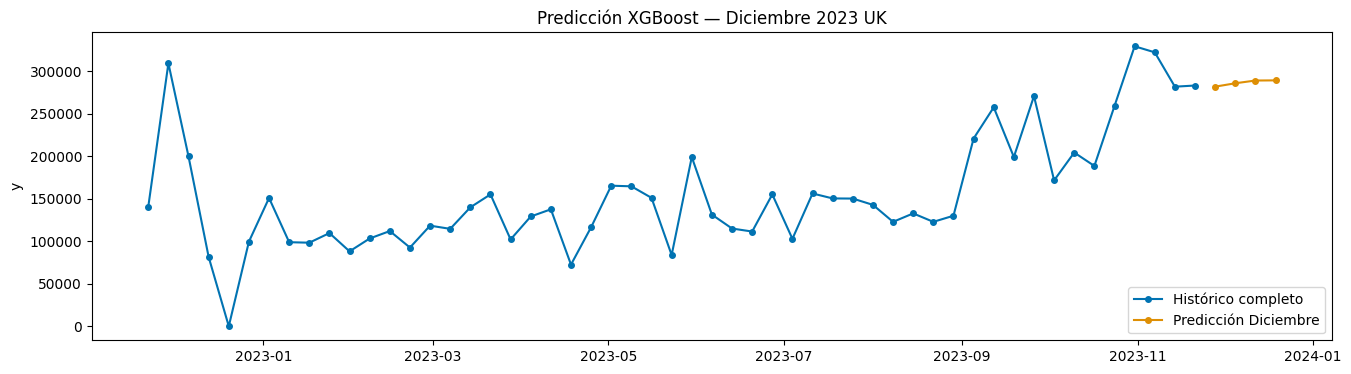

In [ ]:
plot_series(y_full_xgb, y_pred_dec,
            labels=["Histórico completo", "Predicción Diciembre"])
plt.title("Predicción XGBoost — Diciembre 2023 UK")
plt.show()

XGBoost predice unas ventas semanales de entre **£281,668 y £289,058**,
con un **total estimado para diciembre de £1,145,255**.

La predicción muestra una tendencia ligeramente ascendente que continúa
el patrón de las últimas semanas del histórico, lo cual es coherente con
la evolución del año.

* **¿Por qué no vemos un pico navideño?**  
Con un único año de datos, el modelo nunca ha observado un diciembre completo. XGBoost no extrapola estacionalidad que no ha visto en train.

* Esta es una **limitación del dataset disponible**, no del modelo.
Con 2-3 años de histórico el modelo aprendería el pico estacional de
diciembre y lo podría incorporar a la predicción.

# **3. Serie Temporal: Otros países**

Aplicamos el **mismo pipeline XGBoost** que en UK a los 9 mercados
internacionales de TodoVentas S.A, entrenando con la totalidad del
histórico disponible por país.

Las semanas **sin actividad comercial se rellenan con 0**
(suponemos que en esas semanas no hubo pedidos de ese mercado).

La **fiabilidad** de cada predicción está directamente ligada al **volumen de datos disponible:**

| País | Semanas con datos | Fiabilidad |
|---|---|---|
| France | 52 | ✅ Alta |
| Germany | 52 | ✅ Alta |
| Ireland | 49 | ✅ Alta |
| Belgium | 46 | ✅ Aceptable |
| Spain | 44 | ✅ Aceptable |
| Netherlands | 34 | ⚠️ Limitada |
| Portugal | 32 | ⚠️ Limitada |
| Sweden | 27 | ⚠️ Limitada |
| Italy | 24 | ⚠️ Limitada |


France (52 semanas con datos):
  2023-12-04: £5,491
  2023-12-11: £17,827
  2023-12-18: £6,100
  2023-12-25: £6,342
  TOTAL diciembre: £35,760


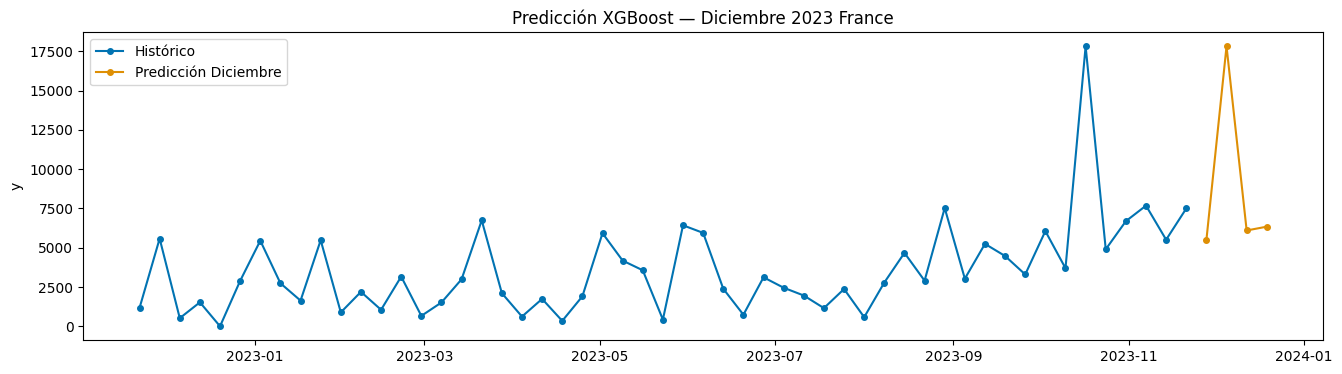


Germany (52 semanas con datos):
  2023-12-04: £4,845
  2023-12-11: £4,349
  2023-12-18: £7,410
  2023-12-25: £5,418
  TOTAL diciembre: £22,022


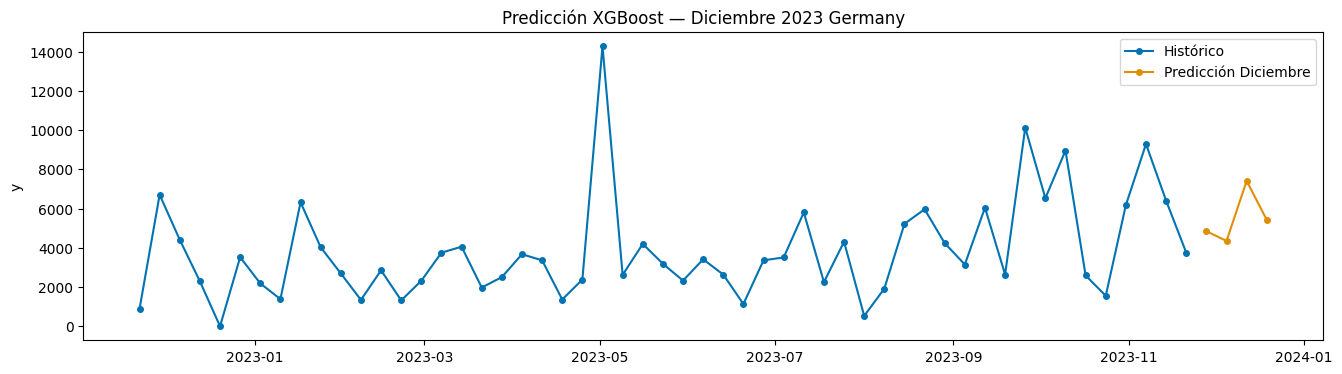


Ireland (49 semanas con datos):
  2023-12-04: £7,614
  2023-12-11: £3,518
  2023-12-18: £5,428
  2023-12-25: £9,910
  TOTAL diciembre: £26,470


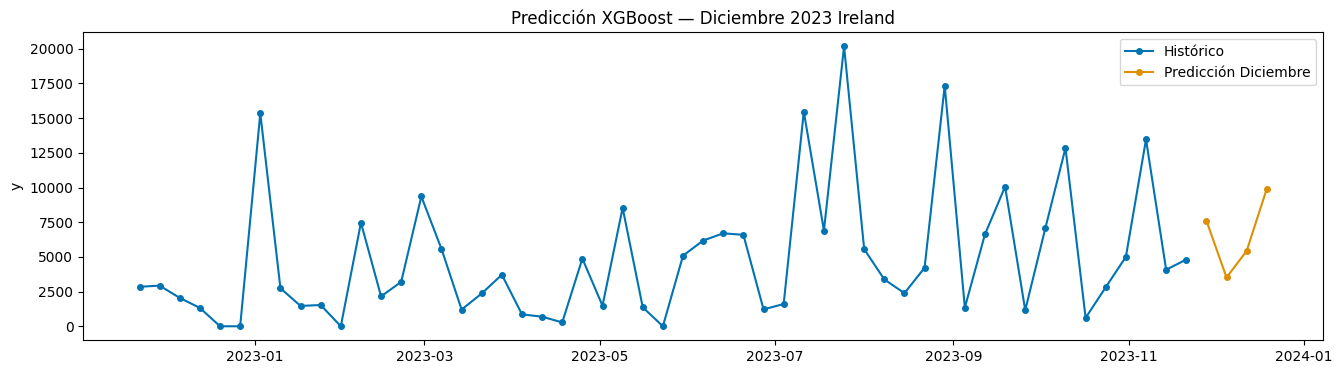


Belgium (46 semanas con datos):
  2023-12-04: £2,039
  2023-12-11: £607
  2023-12-18: £870
  2023-12-25: £1,738
  TOTAL diciembre: £5,254


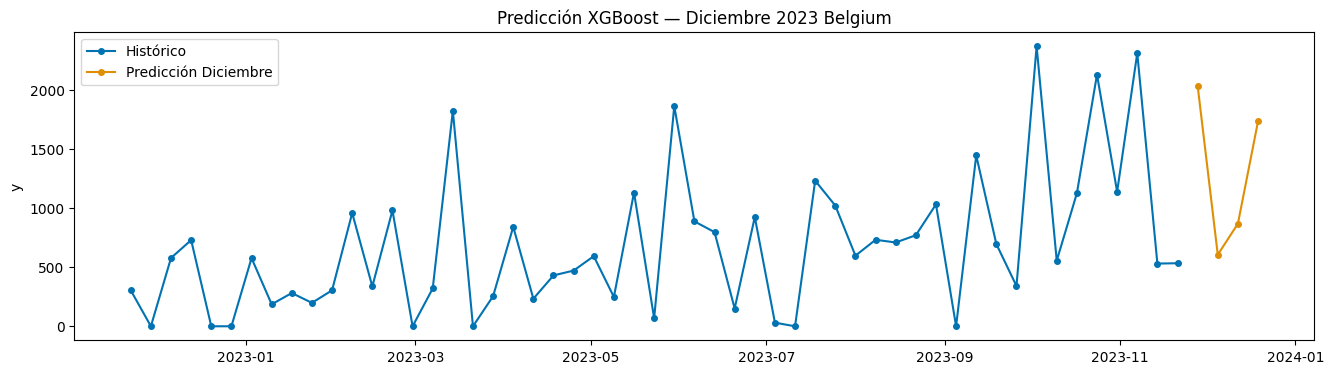


Spain (44 semanas con datos):
  2023-12-04: £1,041
  2023-12-11: £3,039
  2023-12-18: £918
  2023-12-25: £572
  TOTAL diciembre: £5,570


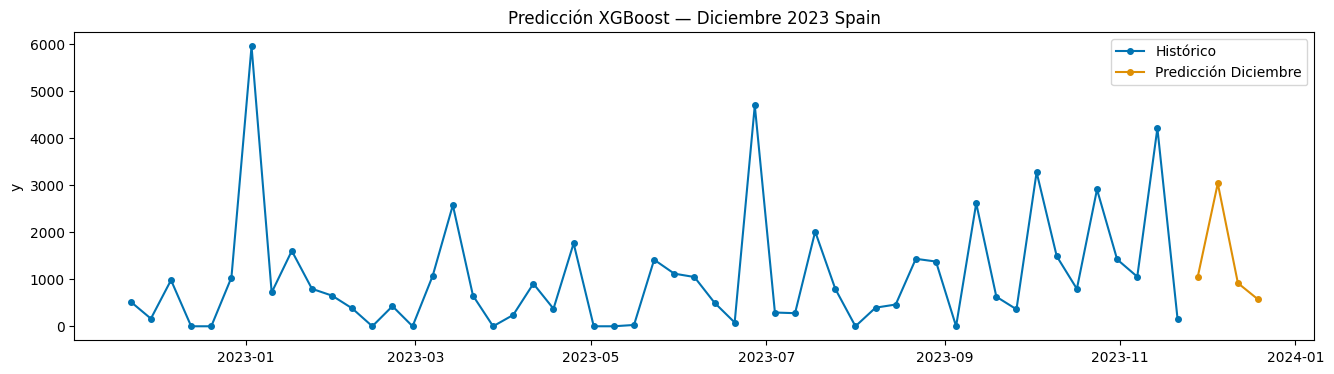


Netherlands (34 semanas con datos):
  2023-12-04: £5,342
  2023-12-11: £150
  2023-12-18: £1,243
  2023-12-25: £3,867
  TOTAL diciembre: £10,601


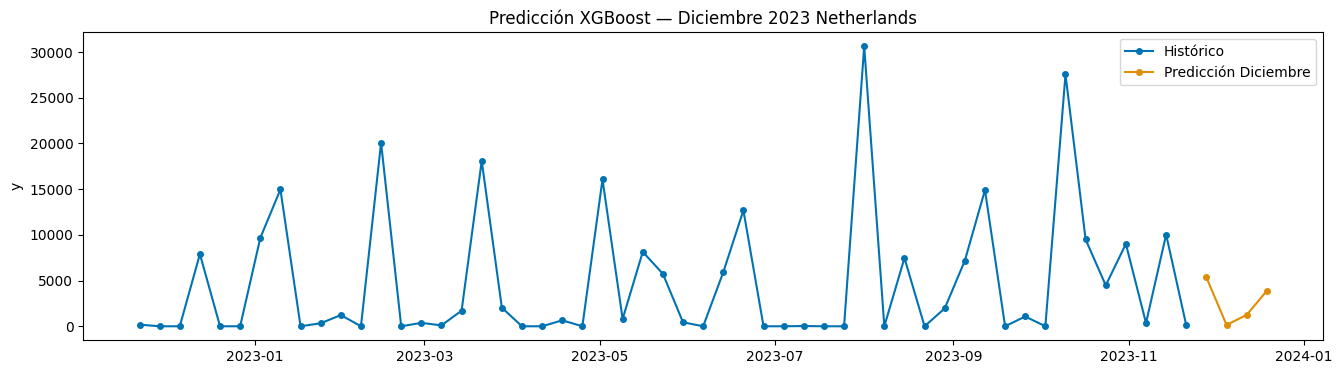


Portugal (32 semanas con datos):
  2023-12-04: £917
  2023-12-11: £197
  2023-12-18: £95
  2023-12-25: £406
  TOTAL diciembre: £1,615


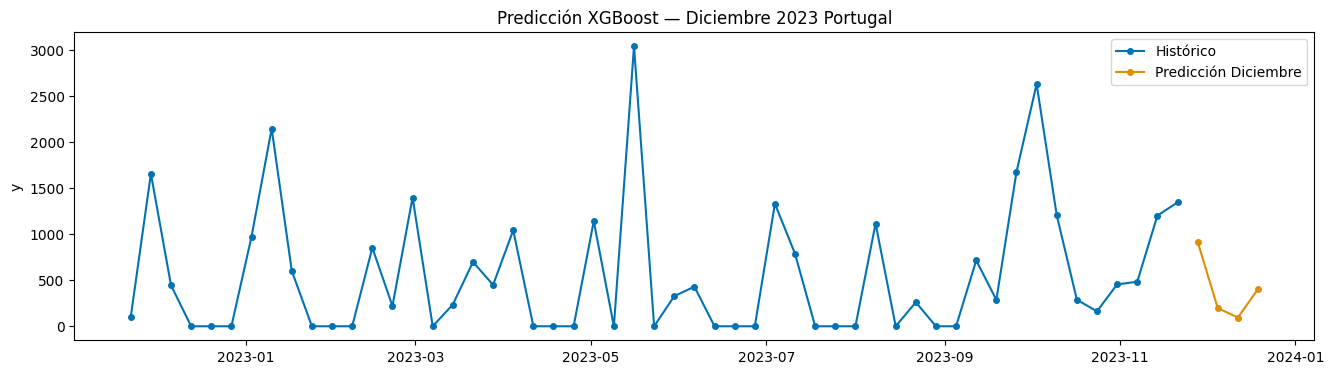


Sweden (27 semanas con datos):
  2023-12-04: £404
  2023-12-11: £509
  2023-12-18: £27
  2023-12-25: £2,151
  TOTAL diciembre: £3,091


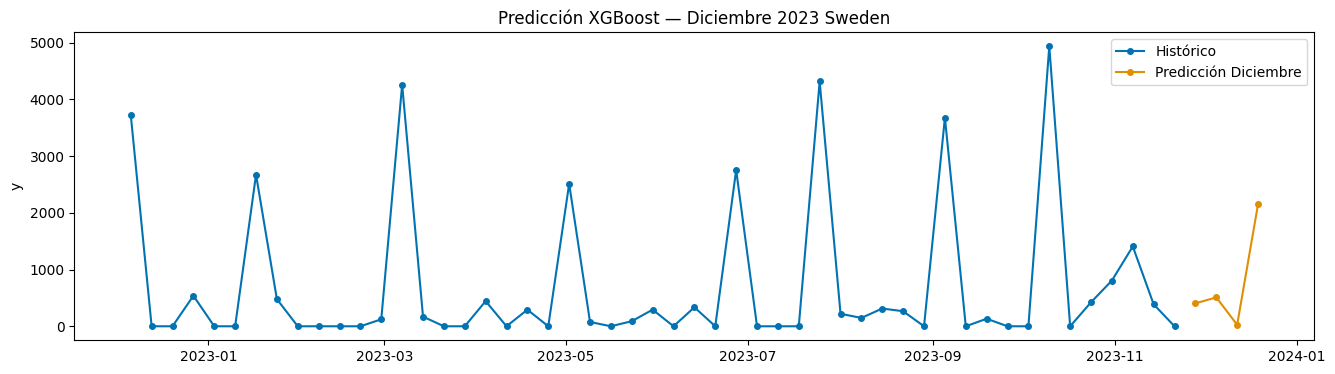


Italy (24 semanas con datos):
  2023-12-04: £472
  2023-12-11: £978
  2023-12-18: £385
  2023-12-25: £348
  TOTAL diciembre: £2,183


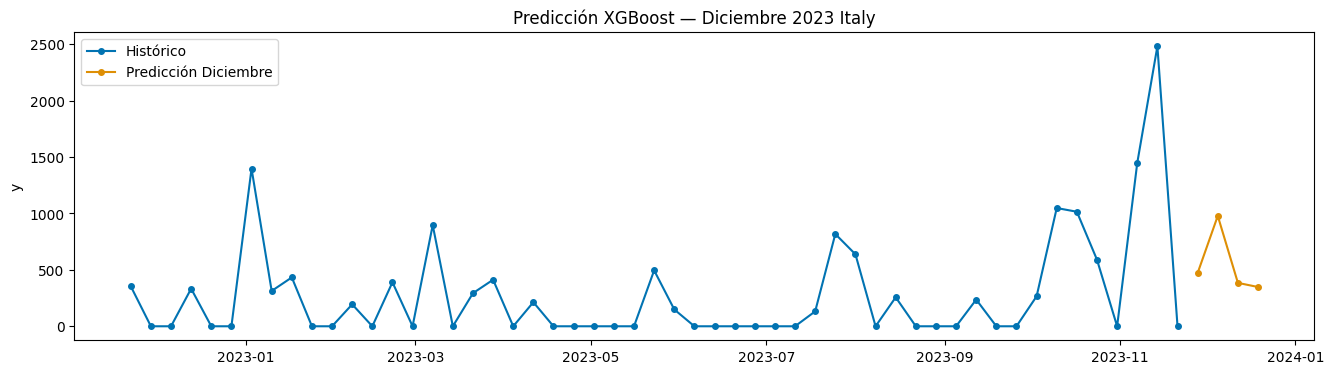

In [ ]:
paises_todos = ["France", "Germany", "Ireland", "Belgium",
                "Spain", "Netherlands", "Portugal", "Sweden", "Italy"]

future_dates = pd.date_range("2023-12-04", periods=4, freq="W-MON")
resultados_paises = {}

for pais in paises_todos:
    df_p = df_ventas_semanal[df_ventas_semanal["Country"] == pais][["ds","y"]].copy()
    df_p = df_p[df_p["ds"] < "2023-12-04"].sort_values("ds").reset_index(drop=True)

    # Rellenar semanas sin ventas con 0
    idx_completo = pd.period_range(
        start=df_p["ds"].min(),
        end="2023-11-27",
        freq="W-MON"
    )
    y_p = pd.Series(
        df_p["y"].values,
        index=pd.PeriodIndex(df_p["ds"].values, freq="W-MON"),
        name="y"
    ).reindex(idx_completo, fill_value=0)

    fh_p = ForecastingHorizon(pd.PeriodIndex(future_dates, freq="W-MON"), is_relative=False)

    forecaster_p = make_reduction(XGBRegressor(objective='reg:squarederror', random_state=42),
                                   strategy="recursive")
    forecaster_p.fit(y_p)
    y_pred_p = forecaster_p.predict(fh_p)

    resultados_paises[pais] = {"semanas": y_pred_p.values, "total": y_pred_p.sum()}

    print(f"\n{pais} ({len(df_p)} semanas con datos):")
    for fecha, pred in zip(future_dates, y_pred_p.values):
        print(f"  {fecha.date()}: £{pred:,.0f}")
    print(f"  TOTAL diciembre: £{y_pred_p.sum():,.0f}")

    plot_series(y_p, y_pred_p, labels=["Histórico", "Predicción Diciembre"])
    plt.title(f"Predicción XGBoost — Diciembre 2023 {pais}")
    plt.show()

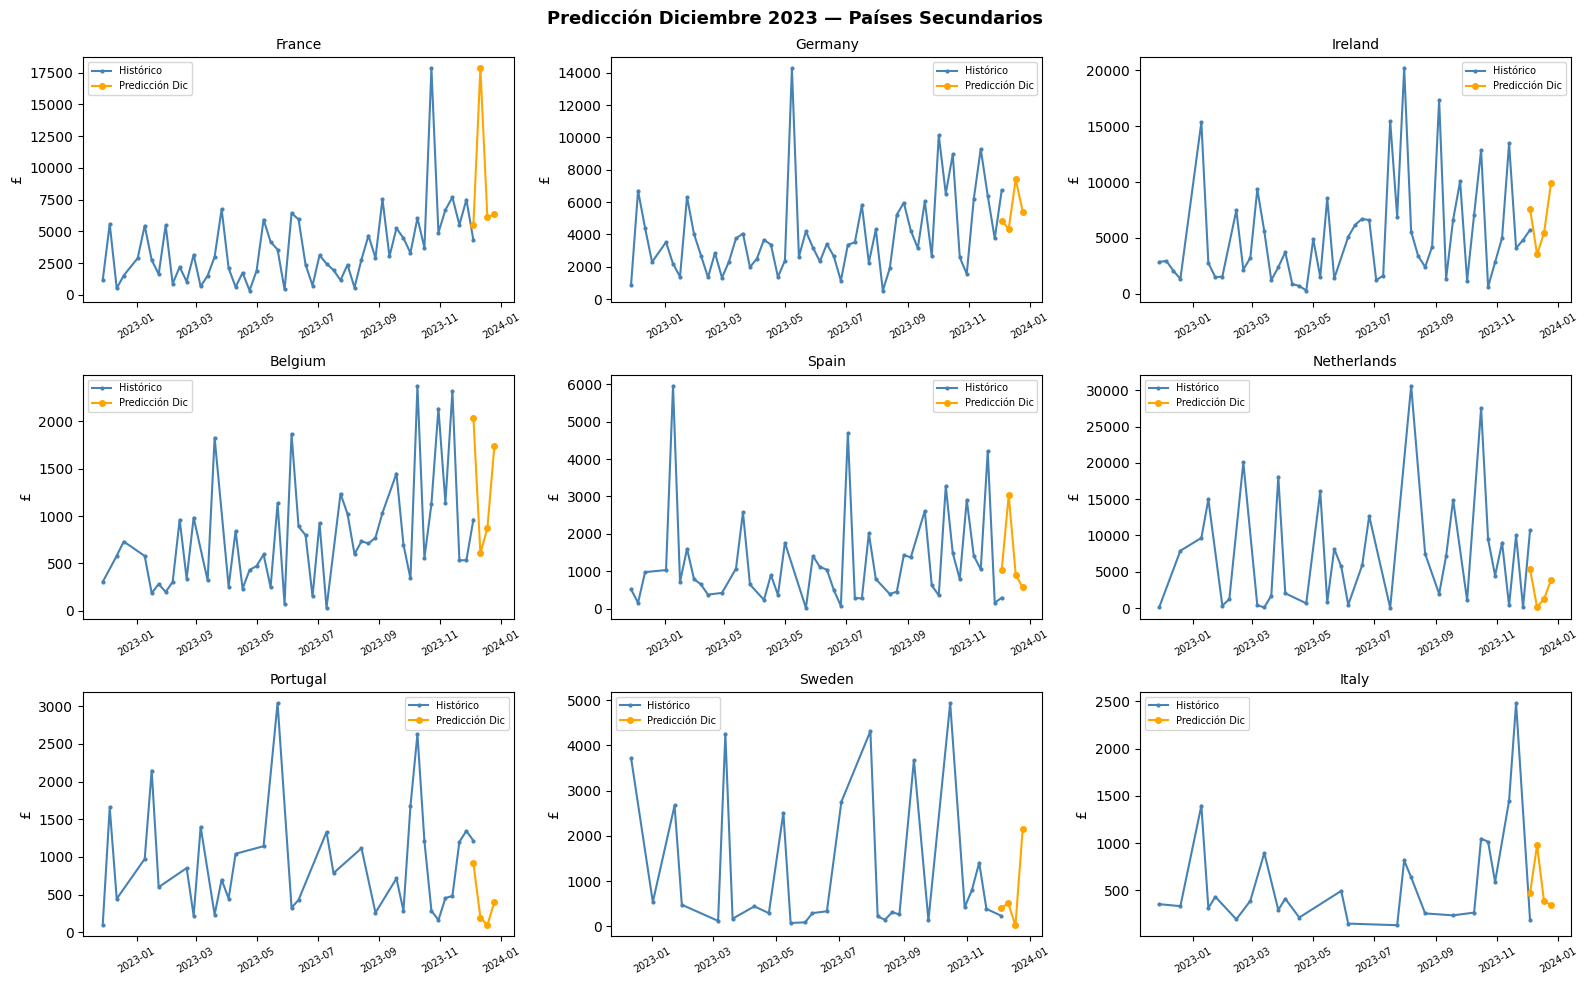

In [ ]:
fig, axes = plt.subplots(3, 3, figsize=(16, 10))
axes = axes.flatten()

for idx, pais in enumerate(paises_todos):
    df_p = df_ventas_semanal[df_ventas_semanal["Country"] == pais][["ds","y"]].copy()
    df_p = df_p.sort_values("ds")

    axes[idx].plot(df_p["ds"], df_p["y"], label="Histórico",
                   marker="o", markersize=2, color="steelblue")
    axes[idx].plot(future_dates, resultados_paises[pais]["semanas"],
                   label="Predicción Dic", color="orange", marker="o", markersize=4)
    axes[idx].set_title(pais, fontsize=10)
    axes[idx].set_ylabel("£")
    axes[idx].tick_params(axis='x', rotation=30, labelsize=7)
    axes[idx].legend(fontsize=7)

plt.suptitle("Predicción Diciembre 2023 — Países Secundarios", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

* **France, Germany, Ireland ->** ofrecen las predicciones más fiables al contar
con casi un año completo de datos. Sus estimaciones son coherentes con el
comportamiento histórico reciente.

* **Belgium, Spain ->**  tienen histórico suficiente aunque su alta volatilidad
limita la precisión semanal.

* **Netherlands, Portugal, Sweden e Italy ->**  operan con pedidos esporádicos
de alto valor, por lo que el modelo predice de forma conservadora basándose
en la actividad reciente. Las cifras reales podrían ser superiores si se
reciben pedidos puntuales de gran volumen.

# **4. Predicción Final TodoVentas S.A**

In [ ]:
todos = {"United Kingdom": 1_145_255}
todos.update({pais: round(v["total"]) for pais, v in resultados_paises.items()})

df_final = pd.DataFrame([
    {"País": pais, "Ventas estimadas (£)": total}
    for pais, total in todos.items()
]).sort_values("Ventas estimadas (£)", ascending=False).reset_index(drop=True)

total_empresa = df_final["Ventas estimadas (£)"].sum()

print("=" * 48)
print("   PREDICCIÓN VENTAS TOTALES — DICIEMBRE 2023")
print("=" * 48)
for _, row in df_final.iterrows():
    pct = row["Ventas estimadas (£)"] / total_empresa * 100
    print(f"  {row['País']:<15} £{row['Ventas estimadas (£)']:>10,.0f}   ({pct:.1f}%)")
print("-" * 48)
print(f"  {'TOTAL EMPRESA':<15} £{total_empresa:>10,.0f}   (100%)")
print("=" * 48)

   PREDICCIÓN VENTAS TOTALES — DICIEMBRE 2023
  United Kingdom  £ 1,145,255   (91.1%)
  France          £    35,760   (2.8%)
  Ireland         £    26,470   (2.1%)
  Germany         £    22,022   (1.8%)
  Netherlands     £    10,601   (0.8%)
  Spain           £     5,570   (0.4%)
  Belgium         £     5,254   (0.4%)
  Sweden          £     3,091   (0.2%)
  Italy           £     2,183   (0.2%)
  Portugal        £     1,615   (0.1%)
------------------------------------------------
  TOTAL EMPRESA   £ 1,257,821   (100%)


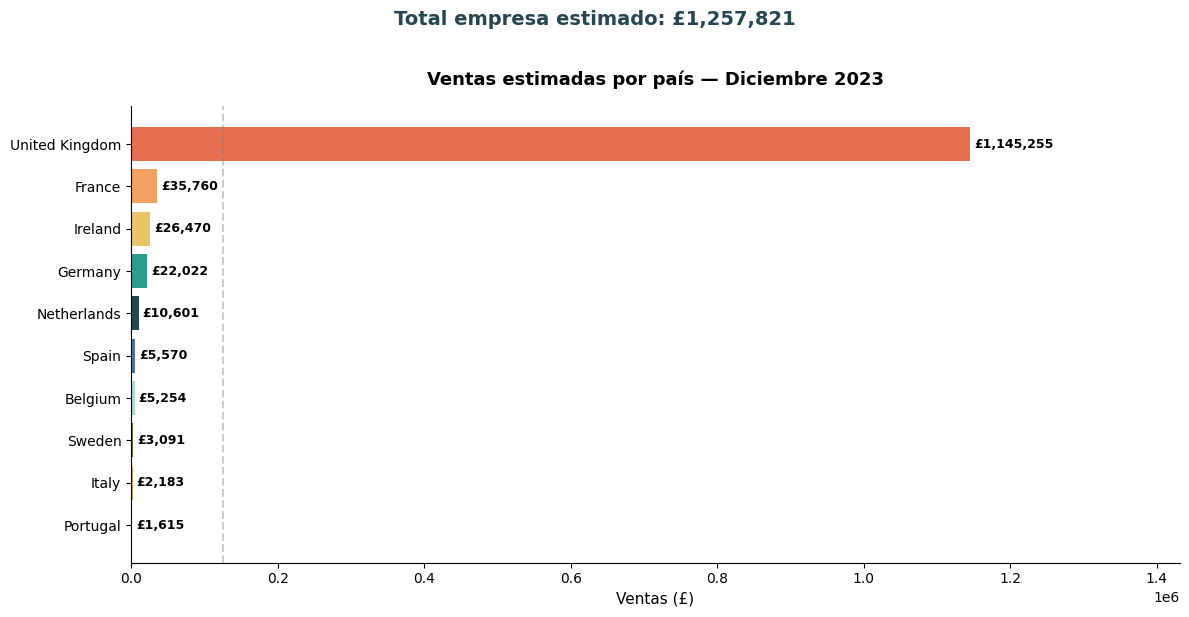

In [ ]:
colores = ["#e76f51","#f4a261","#e9c46a","#2a9d8f","#264653",
           "#457b9d","#a8dadc","#606c38","#dda15e","#bc6c25"]

fig, ax = plt.subplots(figsize=(12, 6))

bars = ax.barh(df_final["País"], df_final["Ventas estimadas (£)"], color=colores)

for i, (_, row) in enumerate(df_final.iterrows()):
    ax.text(row["Ventas estimadas (£)"] + 5000, i,
            f'£{row["Ventas estimadas (£)"]:,.0f}', va='center', fontsize=9, fontweight='bold')

ax.set_xlabel("Ventas (£)", fontsize=11)
ax.set_title("Ventas estimadas por país — Diciembre 2023", fontsize=13, fontweight='bold', pad=15)
ax.invert_yaxis()
ax.set_xlim(0, df_final["Ventas estimadas (£)"].max() * 1.25)
ax.axvline(x=total_empresa/len(df_final), color='gray', linestyle='--', alpha=0.4, label='Media por país')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.suptitle(f"Total empresa estimado: £{total_empresa:,.0f}",
             fontsize=14, fontweight='bold', color='#264653', y=1.02)
plt.tight_layout()
plt.show()

# **5. Conclusiones**

**TodoVentas S.A.** tiene una estimación de **£1,257,821 en ventas para diciembre 2023**, con United Kingdom representando el **91% del total**.

## **Resultados del modelo**

* La serie temporal muestra una **tendencia ascendente sostenida** a lo largo de 2023, lo que es positivo de cara a la ampliación de capital.
* **XGBoost** fue el modelo seleccionado por capturar mejor la variabilidad semanal — SARIMAX produce una línea constante en baseline y Prophet falla en los picos.
* Las **variables exógenas** (festivos, Black Friday, cierre navideño) no consiguieron mejorar las predicciones — el modelo no dispone de suficiente histórico para aprender el efecto de estos eventos.
* La **principal limitación** es contar con un único año de datos. Con 2-3 años de histórico el modelo podría capturar la estacionalidad de diciembre y mejorar la precisión significativamente.
* Los **mercados internacionales** aportan £112,566 combinados. France, Ireland y Germany son los mercados más consolidados.

## **Conclusión para los accionistas**

La estimación de **£1,257,821 en ventas para diciembre 2023** refleja una tendencia de crecimiento consistente a lo largo del año, lo que respalda la decisión de ampliación de capital.

Es importante tener en cuenta que la predicción es **conservadora** — el modelo no dispone de histórico suficiente para anticipar el pico navideño de diciembre. El valor real podría ser superior si se materializan pedidos estacionales. Con más años de datos, la precisión del modelo mejoraría significativamente.

## **Aprendizajes personales**

* Este proyecto me ha permitido aplicar por primera vez un flujo completo de series temporales: desde el preprocesamiento y análisis exploratorio hasta la comparativa de modelos y la predicción final.

* La decisión de trabajar con **frecuencia semanal** fue clave — con solo 13 meses de datos, la frecuencia diaria introducía demasiado ruido y la mensual dejaba pocas observaciones para modelar.

* El resultado más llamativo fue que **SARIMAX obtuvo el mejor MAPE baseline (14.37%)** produciendo una línea constante — en este periodo concreto la media era mejor predicción que cualquier modelo complejo. Al añadir variables exógenas el modelo deja de ser línea recta pero empeora, lo que confirma que con un año de datos no hay suficiente contexto para calibrar la magnitud de eventos como el Black Friday.